# 06b — Predicción de Volatilidad de Carteras (h=22 días)

Pipeline completo: aplica modelos EWMA, HAR-RV, familia GARCH y modelos de árbol con walk-forward
anti-leakage (3 folds), genera predicciones de volatilidad para las **40 carteras seleccionadas**.

| Modelo | Descripción |
|--------|-------------|
| **EWMA** | λ-grid {0.87..0.98} óptimo por cartera |
| **HAR-RV** | Heterogeneous Autoregressive + ElasticNetCV |
| **ARMA_GARCH** | GARCH(1,1) Normal con 5 arranques |
| **GJR_GARCH** | GJR-GARCH leverage effect |
| **EGARCH** | EGARCH asimétrico |
| **GARCH_t** | GARCH(1,1) Student-t |
| **GJR_t** | GJR-GARCH Student-t |
| **AR_GARCH** | AR(1)-GARCH(1,1) |
| **APARCH** | Power ARCH (delta aprendido) |
| **XGB_vol** | XGBoost (16 features HAR+EWMA+macro) |
| **LGB_vol** | LightGBM (16 features) |
| **CAT_vol** | CatBoost ordered boosting |
| **Ensemble** | Pesos ∝ (1/MAE)² |

**Control:** `FORCE_RETRAIN = False` → carga caché | `True` → re-entrena todo (~40-60 min)

In [13]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
if 'ipykernel' not in sys.modules:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNetCV, Ridge as _Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import lightgbm as lgb

warnings.filterwarnings('ignore')
np.random.seed(42)

try:
    from arch import arch_model
    HAS_ARCH = True
    print('arch library disponible — GARCH/EGARCH habilitados')
except ImportError:
    HAS_ARCH = False
    print('WARNING: arch no instalado — GARCH/EGARCH deshabilitados')

def _resolve_root():
    cwd = Path.cwd().resolve()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'data').exists() and (c / 'src').exists():
            return c
    return cwd

ROOT          = _resolve_root()
sys.path.insert(0, str(ROOT))
PROCESSED_DIR = ROOT / 'data' / 'processed'
RESULTS_DIR   = ROOT / 'data' / 'results'
FIG_DIR       = RESULTS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

LAM_EWMA     = 0.94
TRADING_DAYS = 252
ENS_POWER    = 2.0

print(f'Root: {ROOT}')
print(f'arch disponible: {HAS_ARCH}')
print(f'LightGBM: {lgb.__version__}')


arch library disponible — GARCH/EGARCH habilitados
Root: C:\Users\Usuario\Documents\TFG\tfg_xiker_code
arch disponible: True
LightGBM: 4.6.0


In [ ]:
# v7: FORCE_RETRAIN=True garantiza reentrenamiento con los 40 IDs correctos
FORCE_RETRAIN = False

_CACHE = RESULTS_DIR / 'nb06_volatility_predictions.parquet'
_REQUIRED_MODELS = {'EWMA', 'HAR_RV', 'Ensemble'}
_N_PORTFOLIOS    = 40
_N_FOLDS         = 3

_cache_valid = False
if not FORCE_RETRAIN and _CACHE.exists():
    _df_tmp = pd.read_parquet(_CACHE)
    _models = set(_df_tmp['model'].unique())
    _pids   = int(_df_tmp['portfolio_id'].nunique())
    _folds  = int(_df_tmp['fold'].nunique())
    if (_pids >= _N_PORTFOLIOS and _folds >= _N_FOLDS
            and _REQUIRED_MODELS.issubset(_models)):
        _cache_valid = True
        print(f'[CACHE] {_CACHE.name}')
        print(f'  shape={_df_tmp.shape}  portfolios={_pids}  folds={_folds}')
        print(f'  modelos={sorted(_models)}')
    else:
        missing_m = _REQUIRED_MODELS - _models
        print(f'[CACHE INVALIDO] portfolios={_pids}, folds={_folds}, modelos faltantes={missing_m}')
    del _df_tmp

_RUN_TRAINING = not _cache_valid

if not _RUN_TRAINING:
    vol_df = pd.read_parquet(_CACHE)
    vol_df['date']         = pd.to_datetime(vol_df['date'])
    vol_df['portfolio_id'] = vol_df['portfolio_id'].astype(int)
    print('Para re-entrenar: cambia FORCE_RETRAIN = False')
else:
    vol_df = None
    reason = 'FORCE_RETRAIN=True' if FORCE_RETRAIN else 'cache incompleto/inexistente'
    print(f'[TRAIN] Entrenamiento completo activado ({reason})')


[TRAIN] Entrenamiento completo activado (FORCE_RETRAIN=True)


## 1. Carga de datos


In [15]:
port_returns = pd.read_parquet(PROCESSED_DIR / 'portfolios_returns.parquet')
port_returns.columns = port_returns.columns.astype(int)
port_returns = port_returns.sort_index()

# v7 fix: use N04 selection JSON (correct 40 portfolio IDs)
_sel_id_path = PROCESSED_DIR / 'selected_portfolios_ids_optimal_v4.json'
if _sel_id_path.exists():
    with open(_sel_id_path) as _f:
        selected_ids = sorted([int(x) for x in json.load(_f)])
    print(f'[OK] {len(selected_ids)} IDs desde selected_portfolios_ids_optimal_v4.json')
else:
    _mr8 = RESULTS_DIR / 'nb06v8_h22_model_results.parquet'
    if _mr8.exists():
        selected_ids = sorted(pd.read_parquet(_mr8)['portfolio_id'].astype(int).unique().tolist())
        print(f'[OK] {len(selected_ids)} IDs desde nb06v8_h22_model_results.parquet')
    else:
        with open(PROCESSED_DIR / 'selected_portfolios_ids.json') as _f:
            selected_ids = sorted([int(x) for x in json.load(_f)])
        print(f'[WARN] Fallback a selected_portfolios_ids.json: {len(selected_ids)} IDs')
assert len(selected_ids) == 40, f'Expected 40 IDs, got {len(selected_ids)}'

selected_ids = [pid for pid in selected_ids if pid in port_returns.columns]
print(f'Carteras disponibles en port_returns: {len(selected_ids)}')

macro     = pd.read_parquet(PROCESSED_DIR / 'macro_data.parquet')
regime_df = pd.read_parquet(PROCESSED_DIR / 'hmm_regime_features.parquet')

print(f'Retornos  : {port_returns.shape}  [{port_returns.index[0].date()} - {port_returns.index[-1].date()}]')
print(f'Macro     : {macro.shape}')
print(f'Regimen   : {regime_df.shape}')

ref_dates  = port_returns.index
vix_col    = next((c for c in macro.columns if 'vix' in c.lower()), None)
vix_series = macro[vix_col].reindex(ref_dates).ffill() / 100.0 if vix_col else None
rrs_series = None
if 'regime_risk_score' in regime_df.columns:
    rrs_series = regime_df['regime_risk_score'].reindex(ref_dates).ffill()

print(f'VIX feature   : {"si (" + vix_col + ")" if vix_series is not None else "no disponible"}')
print(f'Regime score  : {"si" if rrs_series is not None else "no disponible"}')


[OK] 40 IDs desde selected_portfolios_ids_optimal_v4.json
Carteras disponibles en port_returns: 40
Retornos  : (4793, 4000)  [2007-04-12 - 2026-04-29]
Macro     : (4861, 3)
Regimen   : (4731, 17)
VIX feature   : si (VIX)
Regime score  : no disponible


## 2. Folds walk-forward (ventanas expandibles)

3 folds temporales con ventana de entrenamiento creciente (~3 años de test cada uno).


In [16]:
FOLD_TEST_STARTS = pd.to_datetime(['2016-01-01', '2019-01-01', '2022-01-01'])
FOLD_TEST_ENDS   = pd.to_datetime(['2018-12-31', '2021-12-31', '2024-12-31'])

folds = []
for fold_id, (ts, te) in enumerate(zip(FOLD_TEST_STARTS, FOLD_TEST_ENDS), start=1):
    te      = min(te, ref_dates[-1])
    tr_mask = (ref_dates < ts)
    te_mask = (ref_dates >= ts) & (ref_dates <= te)
    folds.append((fold_id, tr_mask, te_mask))
    n_tr, n_te = int(tr_mask.sum()), int(te_mask.sum())
    print(f'Fold {fold_id}: train={n_tr}d (hasta {ref_dates[tr_mask][-1].date()})'
          f'  |  test={n_te}d ({ref_dates[te_mask][0].date()} -> {ref_dates[te_mask][-1].date()})')


Fold 1: train=2198d (hasta 2015-12-31)  |  test=754d (2016-01-04 -> 2018-12-31)
Fold 2: train=2952d (hasta 2018-12-31)  |  test=757d (2019-01-02 -> 2021-12-31)
Fold 3: train=3709d (hasta 2021-12-31)  |  test=753d (2022-01-03 -> 2024-12-31)


## 3. Funciones de modelo

| Modelo | Optimización |
|--------|-------------|
| **EWMA** | Grid λ ∈ {0.87..0.98}, MSE mínima en training |
| **HAR-RV** | ElasticNetCV(TimeSeriesSplit(5)) |
| **GARCH / GJR-GARCH** | 5 puntos de arranque, selección por log-likelihood |
| **EGARCH** | 3 arranques en log-varianza |
| **XGBoost** | n_estimators=2000 con early stopping (val=últimos 15%) |


In [17]:
def _gp(params, *names, default=0.0):
    for n in names:
        if n in params.index:
            return float(params[n])
    return default


def _best_arch_fit(am, starts):
    best_res, best_ll = None, -np.inf
    for sv in starts:
        try:
            kw = {'disp': 'off', 'show_warning': False, 'options': {'maxiter': 500}}
            if sv is not None:
                kw['starting_values'] = np.asarray(sv, dtype=float)
            res = am.fit(**kw)
            if hasattr(res, 'loglikelihood') and float(res.loglikelihood) > best_ll:
                best_ll = float(res.loglikelihood)
                best_res = res
        except Exception:
            pass
    return best_res


def _ewma_arr(r_arr: np.ndarray, lam: float) -> np.ndarray:
    s = np.empty(len(r_arr))
    s[0] = r_arr[0] ** 2
    for t in range(1, len(r_arr)):
        s[t] = lam * s[t - 1] + (1.0 - lam) * r_arr[t - 1] ** 2
    return s


def _build_tree_features(ret_full: pd.Series, vix_s=None, rrs_s=None) -> pd.DataFrame:
    r  = ret_full.values
    r2 = ret_full ** 2
    rv1   = r2.shift(1)
    rv3   = r2.rolling(3).mean().shift(1)
    rv5   = r2.rolling(5).mean().shift(1)
    rv10  = r2.rolling(10).mean().shift(1)
    rv22  = r2.rolling(22).mean().shift(1)
    rv44  = r2.rolling(44).mean().shift(1)
    ew87  = pd.Series(_ewma_arr(r, 0.87), index=ret_full.index)
    ew94  = pd.Series(_ewma_arr(r, 0.94), index=ret_full.index)
    ew97  = pd.Series(_ewma_arr(r, 0.97), index=ret_full.index)
    vol_of_vol = rv1.rolling(22).std()
    rv_ratio   = (rv1 / rv22.clip(1e-10)).clip(0, 20)
    r_lag      = ret_full.shift(1)
    r_lag_abs  = r_lag.abs()
    neg_lag    = (r_lag < 0).astype(float)
    X = pd.DataFrame({
        'rv1': rv1, 'rv3': rv3, 'rv5': rv5, 'rv10': rv10, 'rv22': rv22, 'rv44': rv44,
        'ew87': ew87, 'ew94': ew94, 'ew97': ew97,
        'vol_of_vol': vol_of_vol, 'rv_ratio': rv_ratio,
        'r_lag': r_lag, 'r_lag_abs': r_lag_abs, 'neg_lag': neg_lag,
    }, index=ret_full.index)
    if vix_s is not None:
        X['vix']     = vix_s.reindex(ret_full.index).ffill().fillna(0)
        X['vix_sq']  = X['vix'] ** 2
        X['vix_rv1'] = X['vix'] * rv_ratio
    if rrs_s is not None:
        X['rrs'] = rrs_s.reindex(ret_full.index).ffill().fillna(0.35)
    return X


def run_ewma(ret_tr: pd.Series, ret_te: pd.Series) -> np.ndarray:
    r_tr = ret_tr.values
    best_lam, best_mse = LAM_EWMA, np.inf
    for lam in [0.87, 0.90, 0.92, 0.94, 0.96, 0.97, 0.98]:
        s2  = _ewma_arr(r_tr, lam)
        mse = float(np.mean((s2[22:] - r_tr[22:] ** 2) ** 2))
        if mse < best_mse:
            best_mse, best_lam = mse, lam
    r  = np.concatenate([r_tr, ret_te.values])
    s2 = _ewma_arr(r, best_lam)
    return s2[len(r_tr):]


def run_har(ret_tr: pd.Series, ret_te: pd.Series) -> np.ndarray:
    full  = pd.concat([ret_tr, ret_te])
    r2    = full ** 2
    rv1   = r2.shift(1)
    rv22  = r2.rolling(22).mean().shift(1)
    X_all = pd.DataFrame({
        'rv1': rv1, 'rv3': r2.rolling(3).mean().shift(1),
        'rv5': r2.rolling(5).mean().shift(1), 'rv22': rv22,
        'rv44': r2.rolling(44).mean().shift(1),
        'vol_of_vol': rv1.rolling(22).std(),
        'rv_ratio': (rv1 / rv22.clip(1e-10)).clip(0, 20),
    })
    n    = len(ret_tr)
    X_tr = X_all.iloc[:n].dropna()
    y_tr = r2.iloc[:n].loc[X_tr.index]
    X_te = X_all.iloc[n:].ffill().fillna(X_all.iloc[:n].median())
    sc   = StandardScaler()
    tscv = TimeSeriesSplit(n_splits=5)
    mdl  = ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9, 1.0],
        alphas=[1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0],
        cv=tscv, max_iter=3000, n_jobs=1,
    )
    mdl.fit(sc.fit_transform(X_tr), y_tr.values)
    return mdl.predict(sc.transform(X_te)).clip(0)


def run_garch(ret_tr, ret_te):
    if not HAS_ARCH: return None
    try:
        r_tr_pct = ret_tr.values * 100.0
        am = arch_model(r_tr_pct, vol='GARCH', p=1, q=1, mean='Constant', rescale=False)
        var_pct = float(np.var(r_tr_pct)); mu0 = float(np.mean(r_tr_pct))
        starts = [None, [mu0, var_pct*0.05, 0.05, 0.90], [mu0, var_pct*0.03, 0.10, 0.85],
                  [mu0, var_pct*0.08, 0.15, 0.80], [mu0, var_pct*0.02, 0.03, 0.94]]
        res = _best_arch_fit(am, starts)
        if res is None: return None
        p = res.params
        omega = _gp(p, 'omega') / 10000.0
        alpha = _gp(p, 'alpha[1]', default=0.05)
        beta  = _gp(p, 'beta[1]',  default=0.90)
        cond_vol = np.asarray(res.conditional_volatility)
        h_prev = float(cond_vol[-1] ** 2) / 10000.0
        r_prev = ret_tr.values[-1]
        out = np.empty(len(ret_te))
        for t in range(len(ret_te)):
            h_t = omega + alpha * r_prev**2 + beta * h_prev
            out[t] = max(h_t, 1e-10)
            h_prev = out[t]; r_prev = ret_te.values[t]
        return out
    except Exception: return None


def run_gjr_garch(ret_tr, ret_te):
    if not HAS_ARCH: return None
    try:
        r_tr_pct = ret_tr.values * 100.0
        am = arch_model(r_tr_pct, vol='GARCH', p=1, o=1, q=1, mean='Constant', rescale=False)
        var_pct = float(np.var(r_tr_pct)); mu0 = float(np.mean(r_tr_pct))
        starts = [None, [mu0, var_pct*0.05, 0.03, 0.10, 0.85], [mu0, var_pct*0.03, 0.05, 0.08, 0.88],
                  [mu0, var_pct*0.08, 0.10, 0.05, 0.80], [mu0, var_pct*0.02, 0.02, 0.15, 0.90]]
        res = _best_arch_fit(am, starts)
        if res is None: return None
        p = res.params
        omega = _gp(p, 'omega') / 10000.0
        alpha = _gp(p, 'alpha[1]', default=0.03)
        gamma = _gp(p, 'gamma[1]', default=0.10)
        beta  = _gp(p, 'beta[1]',  default=0.88)
        cond_vol = np.asarray(res.conditional_volatility)
        h_prev = float(cond_vol[-1] ** 2) / 10000.0
        r_prev = ret_tr.values[-1]
        out = np.empty(len(ret_te))
        for t in range(len(ret_te)):
            ind = 1.0 if r_prev < 0.0 else 0.0
            h_t = omega + (alpha + gamma * ind) * r_prev**2 + beta * h_prev
            out[t] = max(h_t, 1e-10)
            h_prev = out[t]; r_prev = ret_te.values[t]
        return out
    except Exception: return None


def run_egarch(ret_tr, ret_te):
    if not HAS_ARCH: return None
    try:
        r_tr_pct = ret_tr.values * 100.0
        am = arch_model(r_tr_pct, vol='EGARCH', p=1, o=1, q=1, mean='Constant', rescale=False)
        var_pct = float(np.var(r_tr_pct)); mu0 = float(np.mean(r_tr_pct))
        log_var = float(np.log(max(var_pct, 1e-10)))
        starts = [None, [mu0, log_var*0.05, 0.10, -0.05, 0.95],
                  [mu0, log_var*0.10, 0.05, -0.10, 0.92]]
        res = _best_arch_fit(am, starts)
        if res is None: return None
        p = res.params
        omega = _gp(p, 'omega', default=-0.5)
        alpha = _gp(p, 'alpha[1]', default=0.10)
        gamma = _gp(p, 'gamma[1]', 'gamma[0]', default=-0.05)
        beta  = _gp(p, 'beta[1]',  default=0.95)
        E_abs_z = np.sqrt(2.0 / np.pi)
        cond_vol = np.asarray(res.conditional_volatility)
        h_last_pct2 = float(cond_vol[-1] ** 2)
        log_h = np.log(max(h_last_pct2, 1e-10))
        h_pct2 = h_last_pct2
        r_prev_pct = ret_tr.values[-1] * 100.0
        out = np.empty(len(ret_te))
        for t in range(len(ret_te)):
            z = r_prev_pct / max(np.sqrt(h_pct2), 1e-8)
            log_h = omega + alpha * (abs(z) - E_abs_z) + gamma * z + beta * log_h
            log_h = np.clip(log_h, -20.0, 20.0)
            h_pct2 = np.exp(log_h)
            out[t] = h_pct2 / 10000.0
            r_prev_pct = ret_te.values[t] * 100.0
        return out
    except Exception: return None


print('Modelos base definidos: EWMA | HAR-ext | GARCH | GJR-GARCH | EGARCH')


Modelos base definidos: EWMA | HAR-ext | GARCH | GJR-GARCH | EGARCH


In [18]:
def run_garch_t(ret_tr, ret_te):
    if not HAS_ARCH: return None
    try:
        r_tr_pct = ret_tr.values * 100.0
        am = arch_model(r_tr_pct, vol='GARCH', p=1, q=1, mean='Constant', dist='t', rescale=False)
        var_pct = float(np.var(r_tr_pct)); mu0 = float(np.mean(r_tr_pct))
        starts = [None, [mu0, var_pct*0.05, 0.05, 0.90, 8.0], [mu0, var_pct*0.03, 0.10, 0.85, 6.0],
                  [mu0, var_pct*0.08, 0.15, 0.80, 10.0], [mu0, var_pct*0.02, 0.03, 0.94, 5.0]]
        res = _best_arch_fit(am, starts)
        if res is None: return None
        p = res.params
        omega = _gp(p, 'omega') / 10000.0
        alpha = _gp(p, 'alpha[1]', default=0.05)
        beta  = _gp(p, 'beta[1]',  default=0.90)
        cond_vol = np.asarray(res.conditional_volatility)
        h_prev = float(cond_vol[-1] ** 2) / 10000.0
        r_prev = ret_tr.values[-1]
        out = np.empty(len(ret_te))
        for t in range(len(ret_te)):
            h_t = omega + alpha * r_prev**2 + beta * h_prev
            out[t] = max(h_t, 1e-10)
            h_prev = out[t]; r_prev = ret_te.values[t]
        return out
    except Exception: return None


def run_gjr_t(ret_tr, ret_te):
    if not HAS_ARCH: return None
    try:
        r_tr_pct = ret_tr.values * 100.0
        am = arch_model(r_tr_pct, vol='GARCH', p=1, o=1, q=1, mean='Constant', dist='t', rescale=False)
        var_pct = float(np.var(r_tr_pct)); mu0 = float(np.mean(r_tr_pct))
        starts = [None, [mu0, var_pct*0.05, 0.03, 0.10, 0.85, 8.0], [mu0, var_pct*0.03, 0.05, 0.08, 0.88, 6.0],
                  [mu0, var_pct*0.08, 0.10, 0.05, 0.80, 10.0], [mu0, var_pct*0.02, 0.02, 0.15, 0.90, 5.0]]
        res = _best_arch_fit(am, starts)
        if res is None: return None
        p = res.params
        omega = _gp(p, 'omega') / 10000.0
        alpha = _gp(p, 'alpha[1]', default=0.03)
        gamma = _gp(p, 'gamma[1]', default=0.10)
        beta  = _gp(p, 'beta[1]',  default=0.88)
        cond_vol = np.asarray(res.conditional_volatility)
        h_prev = float(cond_vol[-1] ** 2) / 10000.0
        r_prev = ret_tr.values[-1]
        out = np.empty(len(ret_te))
        for t in range(len(ret_te)):
            ind = 1.0 if r_prev < 0.0 else 0.0
            h_t = omega + (alpha + gamma * ind) * r_prev**2 + beta * h_prev
            out[t] = max(h_t, 1e-10)
            h_prev = out[t]; r_prev = ret_te.values[t]
        return out
    except Exception: return None


def run_ar_garch(ret_tr, ret_te):
    if not HAS_ARCH: return None
    try:
        r_tr_pct = ret_tr.values * 100.0
        am = arch_model(r_tr_pct, vol='GARCH', p=1, q=1, mean='ARX', lags=1, rescale=False)
        var_pct = float(np.var(r_tr_pct)); mu0 = float(np.mean(r_tr_pct))
        starts = [None, [mu0, 0.01, var_pct*0.05, 0.05, 0.90], [mu0, 0.05, var_pct*0.03, 0.10, 0.85],
                  [mu0, -0.02, var_pct*0.08, 0.15, 0.80], [mu0, 0.02, var_pct*0.02, 0.03, 0.94]]
        res = _best_arch_fit(am, starts)
        if res is None: return None
        p = res.params
        omega = _gp(p, 'omega') / 10000.0
        alpha = _gp(p, 'alpha[1]', default=0.05)
        beta  = _gp(p, 'beta[1]',  default=0.90)
        cond_vol = np.asarray(res.conditional_volatility)
        resid_arr = np.asarray(res.resid)
        h_prev   = float(cond_vol[-1]**2) / 10000.0
        eps_prev = float(resid_arr[-1]) / 100.0
        mu_dec   = _gp(p, 'Const', default=mu0) / 100.0
        out = np.empty(len(ret_te))
        for t in range(len(ret_te)):
            h_t = omega + alpha * eps_prev**2 + beta * h_prev
            out[t] = max(h_t, 1e-10)
            h_prev = out[t]
            eps_prev = ret_te.values[t] - mu_dec
        return out
    except Exception: return None


def run_aparch(ret_tr, ret_te):
    if not HAS_ARCH: return None
    try:
        r_tr_pct = ret_tr.values * 100.0
        am = arch_model(r_tr_pct, vol='APARCH', p=1, o=1, q=1, mean='Constant', rescale=False)
        var_pct = float(np.var(r_tr_pct)); mu0 = float(np.mean(r_tr_pct))
        starts = [None, [mu0, var_pct*0.05, 0.05,  0.0, 0.90, 2.0],
                  [mu0, var_pct*0.03, 0.10, 0.05, 0.85, 1.5],
                  [mu0, var_pct*0.08, 0.15, -0.05, 0.80, 2.5],
                  [mu0, var_pct*0.02, 0.03, 0.10, 0.94, 1.0]]
        res = _best_arch_fit(am, starts)
        if res is None: return None
        p = res.params
        omega = _gp(p, 'omega')
        alpha = _gp(p, 'alpha[1]', default=0.05)
        gamma = _gp(p, 'gamma[1]', default=0.0)
        beta  = _gp(p, 'beta[1]',  default=0.90)
        delta = max(_gp(p, 'delta', 'power', default=2.0), 0.1)
        cond_vol = np.asarray(res.conditional_volatility)
        sd_prev_pct = float(cond_vol[-1])
        h_pow_prev  = sd_prev_pct ** delta
        r_prev_pct  = ret_tr.values[-1] * 100.0
        out = np.empty(len(ret_te))
        for t in range(len(ret_te)):
            shock = abs(r_prev_pct) + gamma * r_prev_pct
            h_pow_t = omega + alpha * (max(shock, 0.0)**delta) + beta * h_pow_prev
            h_pow_t = max(h_pow_t, 1e-10)
            sd_t_pct = h_pow_t ** (1.0 / delta)
            out[t] = (sd_t_pct / 100.0) ** 2
            h_pow_prev = h_pow_t
            r_prev_pct = ret_te.values[t] * 100.0
        return out
    except Exception: return None


def _tree_split(X_full, r2_full, n_tr, val_frac=0.15):
    X_tr_full = X_full.iloc[:n_tr].dropna()
    y_tr_full = r2_full.iloc[:n_tr].loc[X_tr_full.index]
    X_te      = X_full.iloc[n_tr:].ffill().fillna(X_full.iloc[:n_tr].median())
    n_val     = max(int(len(X_tr_full) * val_frac), 60)
    X_tr_fit  = X_tr_full.iloc[:-n_val]
    X_val_fit = X_tr_full.iloc[-n_val:]
    y_tr_fit  = y_tr_full.iloc[:-n_val]
    y_val_fit = y_tr_full.iloc[-n_val:]
    sc        = StandardScaler().fit(X_tr_fit)
    return (sc.transform(X_tr_fit), np.log1p(y_tr_fit.values * 1e6),
            sc.transform(X_val_fit), np.log1p(y_val_fit.values * 1e6),
            sc.transform(X_te), sc)


def run_xgb_vol(ret_tr, ret_te, vix_s=None, rrs_s=None):
    full = pd.concat([ret_tr, ret_te])
    X    = _build_tree_features(full, vix_s, rrs_s)
    r2   = full ** 2
    Xtr, ytr, Xval, yval, Xte, _ = _tree_split(X, r2, len(ret_tr))
    xgb = XGBRegressor(
        **_XGB_VOL_PARAMS, random_state=42, verbosity=0, early_stopping_rounds=50,
    )
    xgb.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
    return (np.expm1(xgb.predict(Xte)) / 1e6).clip(0)


def run_lgbm_vol(ret_tr, ret_te, vix_s=None, rrs_s=None):
    full = pd.concat([ret_tr, ret_te])
    X    = _build_tree_features(full, vix_s, rrs_s)
    r2   = full ** 2
    Xtr, ytr, Xval, yval, Xte, _ = _tree_split(X, r2, len(ret_tr))
    cb = [lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(-1)]
    model = lgb.LGBMRegressor(
        **_LGB_VOL_PARAMS, bagging_freq=5, random_state=42, verbose=-1,
    )
    model.fit(Xtr, ytr, eval_set=[(Xval, yval)], callbacks=cb)
    return (np.expm1(model.predict(Xte)) / 1e6).clip(0)


def run_catboost_vol(ret_tr, ret_te, vix_s=None, rrs_s=None):
    try:
        from catboost import CatBoostRegressor
        full = pd.concat([ret_tr, ret_te])
        X    = _build_tree_features(full, vix_s, rrs_s)
        r2   = full ** 2
        Xtr, ytr, Xval, yval, Xte, _ = _tree_split(X, r2, len(ret_tr))
        model = CatBoostRegressor(
            **_CAT_VOL_PARAMS, loss_function='RMSE', eval_metric='RMSE',
            random_seed=42, verbose=0, early_stopping_rounds=50,
        )
        model.fit(Xtr, ytr, eval_set=(Xval, yval), use_best_model=True, verbose=0)
        return (np.expm1(model.predict(Xte)) / 1e6).clip(0)
    except Exception: return None


print('Modelos extendidos: GARCH_t | GJR_t | AR_GARCH | APARCH | XGBoost | LightGBM | CatBoost')

# Hiperparametros por defecto — sobreescritos por celda HPO si se ejecuta
_XGB_VOL_PARAMS = {
    'n_estimators': 2000, 'max_depth': 5, 'learning_rate': 0.015,
    'subsample': 0.8, 'colsample_bytree': 0.7,
    'reg_alpha': 0.05, 'reg_lambda': 1.0, 'min_child_weight': 3,
}
_LGB_VOL_PARAMS = {
    'n_estimators': 2000, 'num_leaves': 63, 'learning_rate': 0.015,
    'feature_fraction': 0.7, 'bagging_fraction': 0.8,
    'reg_alpha': 0.05, 'reg_lambda': 1.0, 'min_child_samples': 10,
}
_CAT_VOL_PARAMS = {
    'iterations': 2000, 'depth': 6, 'learning_rate': 0.02, 'l2_leaf_reg': 3,
}
print('Hiperparametros por defecto listos. La celda HPO los actualizara si se ejecuta.')


Modelos extendidos: GARCH_t | GJR_t | AR_GARCH | APARCH | XGBoost | LightGBM | CatBoost
Hiperparametros por defecto listos. La celda HPO los actualizara si se ejecuta.


## 4. Búsqueda de hiperparámetros (Optuna)

Optimización Bayesiana (TPE) sobre los modelos de árbol para volatilidad.
- **Proxy:** 5 carteras representativas × fold 1 (train→2015, test 2016-2018)
- **Objetivo:** minimizar `Ann_vol_MAE` (volatilidad anualizada MAE)
- `FAST_HPO = True` → 10 trials/modelo (~3 min)  |  `False` → 50 trials (~15 min)
- Resultados cacheados en `nb06b_hpo_best_params.json` para re-uso.


In [19]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False
    print('WARNING: optuna no disponible — se usan hiperparametros por defecto')

FAST_HPO    = False  # True: 10 trials/modelo | False: 50 trials
N_TRIALS    = 10 if FAST_HPO else 50
HPO_N_PIDS  = 10     # carteras proxy para la busqueda
HPO_CACHE   = RESULTS_DIR / 'nb06b_hpo_best_params.json'

_hpo_params = {}

if HPO_CACHE.exists() and not FORCE_RETRAIN:
    _hpo_params = json.loads(HPO_CACHE.read_text(encoding='utf-8'))
    print(f'[HPO CACHE] {HPO_CACHE.name}')
    for m, p in _hpo_params.items():
        if isinstance(p, dict):
            print(f'  {m}: {p}')

elif HAS_OPTUNA and _RUN_TRAINING:
    print(f'[HPO] Buscando hiperparametros ({N_TRIALS} trials/modelo, '
          f'{HPO_N_PIDS} carteras proxy)...')
    _, tr_hpo, te_hpo = folds[0]   # fold 1
    _hpo_pids = selected_ids[:HPO_N_PIDS]

    def _hpo_ann_mae(preds_list, trues_list):
        s2p = np.concatenate(preds_list)
        s2t = np.concatenate(trues_list)
        ann_p = np.sqrt(np.maximum(s2p, 0) * TRADING_DAYS)
        ann_t = np.sqrt(np.maximum(s2t, 0) * TRADING_DAYS)
        return float(np.mean(np.abs(ann_p - ann_t)))

    # Pre-calcular features para evitar rebuilds por trial
    _hpo_dc = {}
    for _pid in _hpo_pids:
        _ret    = port_returns[_pid].reindex(ref_dates)
        _ret_tr = _ret[tr_hpo]; _ret_te = _ret[te_hpo]
        _full   = pd.concat([_ret_tr, _ret_te])
        _X      = _build_tree_features(_full, vix_series, rrs_series)
        _r2     = _full ** 2
        _Xtr, _ytr, _Xval, _yval, _Xte, _ = _tree_split(_X, _r2, len(_ret_tr))
        _hpo_dc[_pid] = (_Xtr, _ytr, _Xval, _yval, _Xte, _ret_te.values ** 2)

    def _obj_xgb(trial):
        p = {
            'max_depth'       : trial.suggest_int('max_depth', 3, 7),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
            'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
            'reg_lambda'      : trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        }
        preds, trues = [], []
        for _pid in _hpo_pids:
            Xtr, ytr, Xval, yval, Xte, s2t = _hpo_dc[_pid]
            mdl = XGBRegressor(n_estimators=1000, **p,
                               random_state=42, verbosity=0, early_stopping_rounds=30)
            mdl.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
            preds.append((np.expm1(mdl.predict(Xte)) / 1e6).clip(0))
            trues.append(s2t)
        return _hpo_ann_mae(preds, trues)

    def _obj_lgb(trial):
        p = {
            'num_leaves'      : trial.suggest_int('num_leaves', 15, 127),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
            'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
            'reg_lambda'      : trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        }
        preds, trues = [], []
        for _pid in _hpo_pids:
            Xtr, ytr, Xval, yval, Xte, s2t = _hpo_dc[_pid]
            cb = [lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
            mdl = lgb.LGBMRegressor(n_estimators=1000, **p,
                                     bagging_freq=5, random_state=42, verbose=-1)
            mdl.fit(Xtr, ytr, eval_set=[(Xval, yval)], callbacks=cb)
            preds.append((np.expm1(mdl.predict(Xte)) / 1e6).clip(0))
            trues.append(s2t)
        return _hpo_ann_mae(preds, trues)

    def _obj_cat(trial):
        try:
            from catboost import CatBoostRegressor
            p = {
                'depth'        : trial.suggest_int('depth', 4, 8),
                'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
                'l2_leaf_reg'  : trial.suggest_float('l2_leaf_reg', 1.0, 20.0, log=True),
            }
            preds, trues = [], []
            for _pid in _hpo_pids:
                Xtr, ytr, Xval, yval, Xte, s2t = _hpo_dc[_pid]
                mdl = CatBoostRegressor(iterations=500, **p, loss_function='RMSE',
                                        random_seed=42, verbose=0, early_stopping_rounds=30)
                mdl.fit(Xtr, ytr, eval_set=(Xval, yval), use_best_model=True, verbose=0)
                preds.append((np.expm1(mdl.predict(Xte)) / 1e6).clip(0))
                trues.append(s2t)
            return _hpo_ann_mae(preds, trues)
        except Exception:
            return 1.0

    for _name, _obj in [('xgb', _obj_xgb), ('lgb', _obj_lgb), ('cat', _obj_cat)]:
        _st = optuna.create_study(direction='minimize',
                                   sampler=optuna.samplers.TPESampler(seed=42))
        _st.optimize(_obj, n_trials=N_TRIALS, show_progress_bar=False)
        _hpo_params[_name] = _st.best_params
        print(f'  {_name.upper()} -> Ann_vol_MAE={_st.best_value*100:.3f}%  '
              f'params={_st.best_params}')

    HPO_CACHE.write_text(json.dumps(_hpo_params, indent=2), encoding='utf-8')
    print(f'[HPO OK] Guardado: {HPO_CACHE.name}')

else:
    print('[HPO SKIP] cache valido o optuna no disponible — usando hiperparametros por defecto')

# Aplicar resultados HPO a los diccionarios globales
_ALLOWED_XGB = {'max_depth','learning_rate','subsample','colsample_bytree',
                'reg_alpha','reg_lambda','min_child_weight'}
_ALLOWED_LGB = {'num_leaves','learning_rate','feature_fraction','bagging_fraction',
                'reg_alpha','reg_lambda','min_child_samples'}
_ALLOWED_CAT = {'depth','learning_rate','l2_leaf_reg'}
if _hpo_params.get('xgb'):
    _XGB_VOL_PARAMS.update({k: v for k, v in _hpo_params['xgb'].items()
                             if k in _ALLOWED_XGB})
if _hpo_params.get('lgb'):
    _LGB_VOL_PARAMS.update({k: v for k, v in _hpo_params['lgb'].items()
                             if k in _ALLOWED_LGB})
if _hpo_params.get('cat'):
    _CAT_VOL_PARAMS.update({k: v for k, v in _hpo_params['cat'].items()
                             if k in _ALLOWED_CAT})

print('\n=== Hiperparametros finales para entrenamiento ===')
print(f'  XGB: {_XGB_VOL_PARAMS}')
print(f'  LGB: {_LGB_VOL_PARAMS}')
print(f'  CAT: {_CAT_VOL_PARAMS}')


[HPO] Buscando hiperparametros (50 trials/modelo, 10 carteras proxy)...
  XGB -> Ann_vol_MAE=4.206%  params={'max_depth': 3, 'learning_rate': 0.024910416273385645, 'subsample': 0.6361770187797694, 'colsample_bytree': 0.5594694042421265, 'reg_alpha': 0.015076136840340327, 'reg_lambda': 0.13068224597716535, 'min_child_weight': 2}
  LGB -> Ann_vol_MAE=4.205%  params={'num_leaves': 25, 'learning_rate': 0.03629762373135132, 'feature_fraction': 0.5669067620049938, 'bagging_fraction': 0.8354232249932696, 'reg_alpha': 0.0028912644384523076, 'reg_lambda': 1.4294959625414294, 'min_child_samples': 12}
  CAT -> Ann_vol_MAE=4.210%  params={'depth': 4, 'learning_rate': 0.03674059202635224, 'l2_leaf_reg': 6.054365855469246}
[HPO OK] Guardado: nb06b_hpo_best_params.json

=== Hiperparametros finales para entrenamiento ===
  XGB: {'n_estimators': 2000, 'max_depth': 3, 'learning_rate': 0.024910416273385645, 'subsample': 0.6361770187797694, 'colsample_bytree': 0.5594694042421265, 'reg_alpha': 0.0150761368

## 5. Entrenamiento walk-forward

Para cada fold y cada cartera: todos los modelos. `sigma2_true = r_t²` (varianza realizada diaria).

**Tiempo estimado:** ~40-60 minutos (GARCH×5 variantes dominan; XGBoost añade ~15 min extra).


In [20]:
if _RUN_TRAINING:

    all_vol_rows      = []
    garch_failures    = set()
    gjr_failures      = set()
    egarch_failures   = set()
    lgbm_failures     = set()
    cat_failures      = set()
    garch_t_failures  = set()
    gjr_t_failures    = set()
    ar_garch_failures = set()
    aparch_failures   = set()

    for fold_id, tr_mask, te_mask in folds:
        te_dates = ref_dates[te_mask]
        print(f'\n=== Fold {fold_id}/3  |  test: {te_dates[0].date()} -> {te_dates[-1].date()} ({te_mask.sum()}d) ===')

        for p_idx, pid in enumerate(selected_ids):
            ret    = port_returns[pid].reindex(ref_dates)
            r2_te  = (ret ** 2)[te_mask].values
            ret_tr = ret[tr_mask]
            ret_te = ret[te_mask]

            def _save(model_name, preds):
                for d, s2p, s2t in zip(te_dates, preds, r2_te):
                    all_vol_rows.append({
                        'date': d, 'portfolio_id': pid, 'fold': fold_id,
                        'model': model_name, 'sigma2_true': float(s2t),
                        'sigma2_pred': float(max(s2p, 0.0)),
                    })

            _save('EWMA', run_ewma(ret_tr, ret_te))
            _save('HAR_RV', run_har(ret_tr, ret_te))

            if pid not in garch_failures:
                g = run_garch(ret_tr, ret_te)
                if g is not None: _save('ARMA_GARCH', g)
                else: garch_failures.add(pid)

            if pid not in gjr_failures:
                gj = run_gjr_garch(ret_tr, ret_te)
                if gj is not None: _save('GJR_GARCH', gj)
                else: gjr_failures.add(pid)

            if pid not in egarch_failures:
                eg = run_egarch(ret_tr, ret_te)
                if eg is not None: _save('EGARCH', eg)
                else: egarch_failures.add(pid)

            if pid not in garch_t_failures:
                gt = run_garch_t(ret_tr, ret_te)
                if gt is not None: _save('GARCH_t', gt)
                else: garch_t_failures.add(pid)

            if pid not in gjr_t_failures:
                gjt = run_gjr_t(ret_tr, ret_te)
                if gjt is not None: _save('GJR_t', gjt)
                else: gjr_t_failures.add(pid)

            if pid not in ar_garch_failures:
                arg = run_ar_garch(ret_tr, ret_te)
                if arg is not None: _save('AR_GARCH', arg)
                else: ar_garch_failures.add(pid)

            if pid not in aparch_failures:
                ap = run_aparch(ret_tr, ret_te)
                if ap is not None: _save('APARCH', ap)
                else: aparch_failures.add(pid)

            _save('XGB_vol', run_xgb_vol(ret_tr, ret_te, vix_s=vix_series, rrs_s=rrs_series))

            if pid not in lgbm_failures:
                lm = run_lgbm_vol(ret_tr, ret_te, vix_s=vix_series, rrs_s=rrs_series)
                if lm is not None: _save('LGB_vol', lm)
                else: lgbm_failures.add(pid)

            if pid not in cat_failures:
                cb = run_catboost_vol(ret_tr, ret_te, vix_s=vix_series, rrs_s=rrs_series)
                if cb is not None: _save('CAT_vol', cb)
                else: cat_failures.add(pid)

            if (p_idx + 1) % 10 == 0 or (p_idx + 1) == len(selected_ids):
                print(f'  {p_idx + 1}/{len(selected_ids)} carteras completadas')

    print(f'\nEntrenamiento completo: {len(all_vol_rows):,} filas')
    for name, fails in [('GARCH', garch_failures), ('GJR', gjr_failures),
                        ('EGARCH', egarch_failures), ('GARCH_t', garch_t_failures),
                        ('GJR_t', gjr_t_failures), ('AR_GARCH', ar_garch_failures),
                        ('APARCH', aparch_failures), ('LGB', lgbm_failures), ('CAT', cat_failures)]:
        status = f'fallo en: {sorted(fails)}' if fails else f'{len(selected_ids)}/{len(selected_ids)} OK'
        print(f'  {name}: {status}')

else:
    print('[SKIP] Training omitido (cache valido cargado).')



=== Fold 1/3  |  test: 2016-01-04 -> 2018-12-31 (754d) ===
  10/40 carteras completadas
  20/40 carteras completadas
  30/40 carteras completadas
  40/40 carteras completadas

=== Fold 2/3  |  test: 2019-01-02 -> 2021-12-31 (757d) ===
  10/40 carteras completadas
  20/40 carteras completadas
  30/40 carteras completadas
  40/40 carteras completadas

=== Fold 3/3  |  test: 2022-01-03 -> 2024-12-31 (753d) ===
  10/40 carteras completadas
  20/40 carteras completadas
  30/40 carteras completadas
  40/40 carteras completadas

Entrenamiento completo: 1,086,720 filas
  GARCH: 40/40 OK
  GJR: 40/40 OK
  EGARCH: 40/40 OK
  GARCH_t: 40/40 OK
  GJR_t: 40/40 OK
  AR_GARCH: 40/40 OK
  APARCH: 40/40 OK
  LGB: 40/40 OK
  CAT: 40/40 OK


## 6. Ensemble y Stacking

**Ensemble:** pesos `(1/MAE)²` — da más protagonismo a los modelos más precisos.


In [21]:
if _RUN_TRAINING:

    vol_df = pd.DataFrame(all_vol_rows)
    vol_df['date']         = pd.to_datetime(vol_df['date'])
    vol_df['portfolio_id'] = vol_df['portfolio_id'].astype(int)
    vol_df['fold']         = vol_df['fold'].astype(int)

    BASE_MODELS = ['EWMA','HAR_RV','ARMA_GARCH','GJR_GARCH','EGARCH',
                   'GARCH_t','GJR_t','AR_GARCH','APARCH','XGB_vol','LGB_vol','CAT_vol']
    avail_base  = [m for m in BASE_MODELS if m in vol_df['model'].unique()]
    print(f'Modelos base disponibles: {avail_base}')

    model_mae = (
        vol_df[vol_df['model'].isin(avail_base)]
        .groupby('model')
        .apply(lambda g: float(np.mean(np.abs(g['sigma2_pred'] - g['sigma2_true']))))
    )
    inv_pow = {m: (1.0 / max(model_mae[m], 1e-12)) ** ENS_POWER for m in avail_base}
    total_w = sum(inv_pow.values())
    weights = {m: v / total_w for m, v in inv_pow.items()}

    print(f'\nPesos ensemble (1/MAE)^{ENS_POWER:.0f}:')
    for m, w in sorted(weights.items(), key=lambda x: -x[1]):
        print(f'  {m:15s}: w={w:.4f}  MAE={model_mae[m]*1e6:.2f}e-6')

    base_df  = vol_df[vol_df['model'].isin(avail_base)].copy()
    true_ref = base_df.groupby(['date','portfolio_id','fold'])['sigma2_true'].first().reset_index()
    pivot = (base_df.pivot_table(index=['date','portfolio_id','fold'], columns='model',
                                  values='sigma2_pred', aggfunc='first')
             .reset_index().merge(true_ref, on=['date','portfolio_id','fold']))
    model_cols = [m for m in avail_base if m in pivot.columns]
    w_arr  = np.array([weights[m] for m in model_cols])
    p_mat  = pivot[model_cols].values.copy()
    w_mat  = np.tile(w_arr, (len(p_mat), 1))
    w_mat[np.isnan(p_mat)] = 0.0
    p_mat  = np.nan_to_num(p_mat, nan=0.0)
    w_sum  = w_mat.sum(axis=1)
    ens_preds = np.where(w_sum > 0, (p_mat * w_mat).sum(axis=1) / w_sum, np.nan)
    ens_df = pivot[['date','portfolio_id','fold','sigma2_true']].copy()
    ens_df['model']       = 'Ensemble'
    ens_df['sigma2_pred'] = np.clip(ens_preds, 0, None)
    vol_df = pd.concat([vol_df, ens_df], ignore_index=True)

    print(f'\nvol_df final: {vol_df.shape}')
    print(f'Modelos: {sorted(vol_df["model"].unique())}')

    # Guardar cache inmediatamente tras entrenamiento
    vol_df.to_parquet(_CACHE, index=False)
    print(f'[OK] Cache guardado: {_CACHE.name}')

else:
    print('[SKIP] Ensemble omitido (cache valido cargado).')
    avail_base = sorted(set(vol_df['model'].unique()) - {'Ensemble'})
    weights = {}


Modelos base disponibles: ['EWMA', 'HAR_RV', 'ARMA_GARCH', 'GJR_GARCH', 'EGARCH', 'GARCH_t', 'GJR_t', 'AR_GARCH', 'APARCH', 'XGB_vol', 'LGB_vol', 'CAT_vol']

Pesos ensemble (1/MAE)^2:
  CAT_vol        : w=0.1111  MAE=62.01e-6
  XGB_vol        : w=0.1111  MAE=62.01e-6
  LGB_vol        : w=0.1099  MAE=62.36e-6
  EGARCH         : w=0.0836  MAE=71.49e-6
  GJR_GARCH      : w=0.0776  MAE=74.22e-6
  GJR_t          : w=0.0767  MAE=74.64e-6
  EWMA           : w=0.0763  MAE=74.82e-6
  AR_GARCH       : w=0.0758  MAE=75.07e-6
  ARMA_GARCH     : w=0.0754  MAE=75.29e-6
  GARCH_t        : w=0.0733  MAE=76.35e-6
  APARCH         : w=0.0688  MAE=78.79e-6
  HAR_RV         : w=0.0603  MAE=84.18e-6

vol_df final: (1177280, 6)
Modelos: ['APARCH', 'ARMA_GARCH', 'AR_GARCH', 'CAT_vol', 'EGARCH', 'EWMA', 'Ensemble', 'GARCH_t', 'GJR_GARCH', 'GJR_t', 'HAR_RV', 'LGB_vol', 'XGB_vol']
[OK] Cache guardado: nb06_volatility_predictions.parquet


## 7. Métricas de evaluación

**Ann_vol_MAE**: error en vol anualizada (%). **Qlike**: quasi-likelihood de Patton (2011).


In [22]:
def vol_metrics(g: pd.DataFrame) -> pd.Series:
    s2p  = g['sigma2_pred'].values
    s2t  = g['sigma2_true'].values
    mae  = float(np.mean(np.abs(s2p - s2t)))
    rmse = float(np.sqrt(np.mean((s2p - s2t) ** 2)))
    ann_p = np.sqrt(np.maximum(s2p, 0) * TRADING_DAYS)
    ann_t = np.sqrt(np.maximum(s2t, 0) * TRADING_DAYS)
    ann_mae = float(np.mean(np.abs(ann_p - ann_t)))
    # MAPE on annualized vol (ratio metric, scale-independent)
    mape_ann = float(np.mean(np.abs(ann_p - ann_t) / np.maximum(ann_t, 1e-6)) * 100.0)
    # Theil's U: RMSE_model / RMSE_naive (naive = persistence: sigma2_t+1 = sigma2_t)
    s2t_lag  = np.empty_like(s2t); s2t_lag[0] = s2t[0]; s2t_lag[1:] = s2t[:-1]
    rmse_naive = float(np.sqrt(np.mean((s2t - s2t_lag) ** 2))) + 1e-10
    theil_u  = rmse / rmse_naive
    # Bias: mean predicted annualized vol / mean realized (1.0 = unbiased)
    bias = float(np.mean(ann_p) / max(float(np.mean(ann_t)), 1e-6))
    eps   = 1e-8
    ratio = s2p / (s2t + eps)
    qlike = float(np.mean(ratio - np.log(ratio + eps) - 1.0))
    corr  = float(np.corrcoef(ann_p, ann_t)[0, 1]) if len(ann_p) > 1 else 0.0
    return pd.Series({'Ann_vol_MAE': ann_mae, 'MAPE_ann_vol': mape_ann,
                      'Theil_U': theil_u, 'Bias': bias,
                      'MAE_s2': mae, 'RMSE_s2': rmse,
                      'Qlike': qlike, 'Corr_ann': corr})


metrics = (
    vol_df.groupby('model')
    .apply(vol_metrics)
    .sort_values('Ann_vol_MAE')
)
best_model = metrics.index[0]

print('=== Comparativa de modelos (todos los folds) ===')
print(metrics.round(6).to_string())
print(f'\nMejor modelo (Ann_vol_MAE minimo): {best_model}')

metrics_by_fold = (
    vol_df.groupby(['fold', 'model'])
    .apply(vol_metrics)[['Ann_vol_MAE', 'Qlike']]
    .sort_values(['fold', 'Ann_vol_MAE'])
)
print('\n=== Top-3 por fold (Ann_vol_MAE) ===')
for fold_id in [1, 2, 3]:
    sub = metrics_by_fold.loc[fold_id].sort_values('Ann_vol_MAE')
    print(f'  Fold {fold_id}: '
          + '  |  '.join(f'{m}: {sub.loc[m, "Ann_vol_MAE"]*100:.3f}%'
                         for m in sub.index[:3]))

display(metrics.style
    .background_gradient(cmap='RdYlGn_r', subset=['Ann_vol_MAE', 'MAPE_ann_vol', 'Theil_U', 'MAE_s2', 'RMSE_s2', 'Qlike'])
    .background_gradient(cmap='RdYlGn', subset=['Corr_ann'])
    .background_gradient(cmap='coolwarm', subset=['Bias'])
    .format({'Ann_vol_MAE': '{:.6f}', 'MAPE_ann_vol': '{:.2f}', 'Theil_U': '{:.4f}',
             'Bias': '{:.3f}', 'MAE_s2': '{:.8f}', 'RMSE_s2': '{:.8f}',
             'Qlike': '{:.6f}', 'Corr_ann': '{:.4f}'})
    .set_caption('Metricas por modelo - todos los folds'))


=== Comparativa de modelos (todos los folds) ===
            Ann_vol_MAE  MAPE_ann_vol   Theil_U      Bias    MAE_s2   RMSE_s2       Qlike  Corr_ann
model                                                                                              
CAT_vol        0.054102    638.860191  0.849865  0.777739  0.000062  0.000301   32.708607  0.538209
XGB_vol        0.054166    641.023472  0.845472  0.780938  0.000062  0.000299   33.049697  0.541707
LGB_vol        0.054600    663.126603  0.844685  0.796634  0.000062  0.000299   34.974824  0.520981
Ensemble       0.061066   1025.368603  1.168117  1.204057  0.000068  0.000278   80.688127  0.529394
EGARCH         0.064678   1121.636694  0.774096  1.313839  0.000071  0.000274   95.590541  0.526948
EWMA           0.064753   1072.883712  0.793921  1.274863  0.000075  0.000281   92.900233  0.499543
GJR_t          0.065388   1098.333799  0.785491  1.322270  0.000075  0.000278   96.827677  0.520994
GJR_GARCH      0.065696   1117.569660  0.780646  1.

,Ann_vol_MAE,MAPE_ann_vol,Theil_U,Bias,MAE_s2,RMSE_s2,Qlike,Corr_ann
model,,,,,,,,
CAT_vol,0.054102,638.86,0.8499,0.778,0.00006201,0.00030084,32.708607,0.5382
XGB_vol,0.054166,641.02,0.8455,0.781,0.00006201,0.00029928,33.049697,0.5417
LGB_vol,0.054600,663.13,0.8447,0.797,0.00006236,0.00029900,34.974824,0.5210
Ensemble,0.061066,1025.37,1.1681,1.204,0.00006769,0.00027809,80.688127,0.5294
EGARCH,0.064678,1121.64,0.7741,1.314,0.00007149,0.00027401,95.590541,0.5269
EWMA,0.064753,1072.88,0.7939,1.275,0.00007482,0.00028103,92.900233,0.4995
GJR_t,0.065388,1098.33,0.7855,1.322,0.00007464,0.00027805,96.827677,0.5210
GJR_GARCH,0.065696,1117.57,0.7806,1.332,0.00007422,0.00027633,98.075295,0.5237
AR_GARCH,0.066966,1157.02,0.7813,1.347,0.00007507,0.00027657,102.542311,0.5119


## 8. Visualizaciones


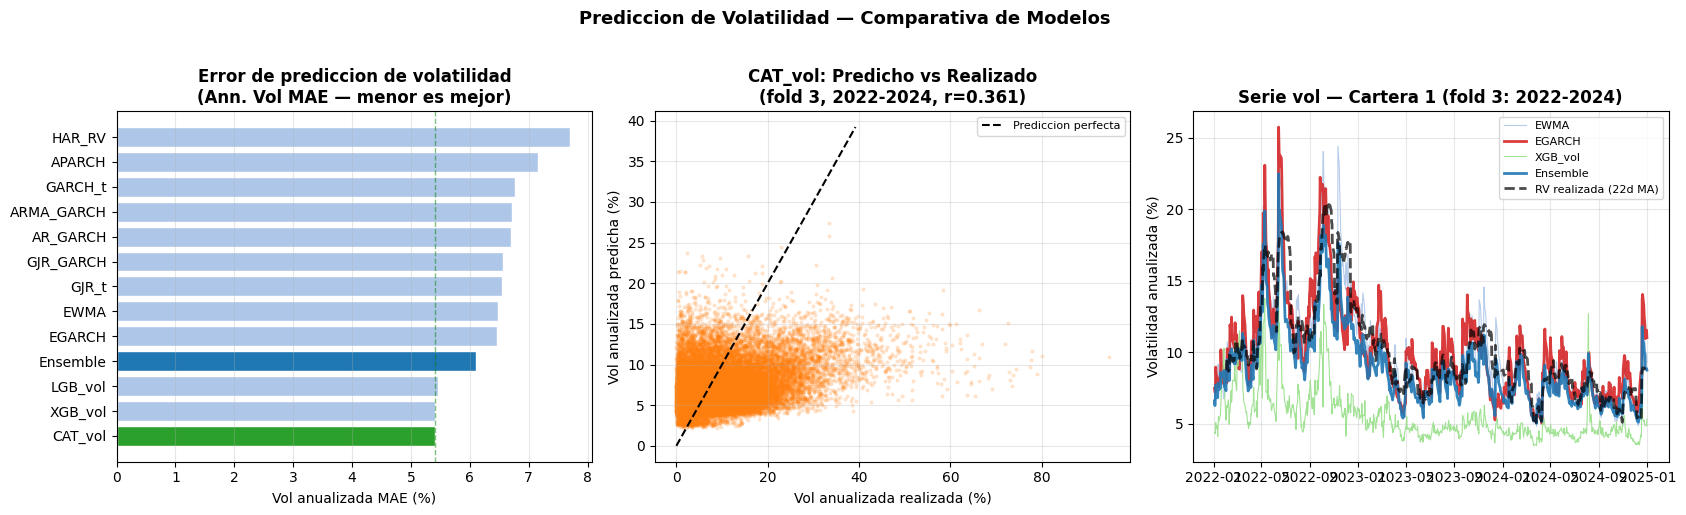

[OK] 06b_volatility_model_comparison.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

mae_sorted = metrics['Ann_vol_MAE'].sort_values()
colors = ['#2ca02c' if m == best_model else
          '#1f77b4' if m == 'Ensemble' else '#aec7e8'
          for m in mae_sorted.index]
axes[0].barh(mae_sorted.index, mae_sorted.values * 100, color=colors, edgecolor='white')
axes[0].axvline(mae_sorted.min() * 100, color='green', ls='--', alpha=0.5, lw=1)
axes[0].set_xlabel('Vol anualizada MAE (%)')
axes[0].set_title('Error de prediccion de volatilidad\n(Ann. Vol MAE — menor es mejor)', fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

sub3    = vol_df[(vol_df['model'] == best_model) & (vol_df['fold'] == 3)]
ann_t3  = np.sqrt(sub3['sigma2_true'].clip(0) * TRADING_DAYS) * 100
ann_p3  = np.sqrt(sub3['sigma2_pred'].clip(0) * TRADING_DAYS) * 100
axes[1].scatter(ann_t3, ann_p3, alpha=0.15, s=4, color='#ff7f0e', rasterized=True)
lim = max(float(ann_t3.quantile(0.99)), float(ann_p3.quantile(0.99)))
axes[1].plot([0, lim], [0, lim], 'k--', lw=1.5, label='Prediccion perfecta')
r_corr = float(np.corrcoef(ann_t3, ann_p3)[0, 1])
axes[1].set_xlabel('Vol anualizada realizada (%)')
axes[1].set_ylabel('Vol anualizada predicha (%)')
axes[1].set_title(f'{best_model}: Predicho vs Realizado\n(fold 3, 2022-2024, r={r_corr:.3f})', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

pid_ex  = selected_ids[0]
palette = {'EWMA': '#aec7e8', 'HAR_RV': '#ffbb78', 'EGARCH': '#d62728',
           'XGB_vol': '#98df8a', 'Ensemble': '#1f77b4'}
for mdl in ['EWMA', 'EGARCH', 'XGB_vol', 'Ensemble']:
    sub_ts = vol_df[(vol_df['model'] == mdl) & (vol_df['fold'] == 3) &
                    (vol_df['portfolio_id'] == pid_ex)].set_index('date')
    if len(sub_ts) == 0: continue
    ann_v = np.sqrt(sub_ts['sigma2_pred'].clip(0) * TRADING_DAYS) * 100
    lw    = 2.0 if mdl in ('Ensemble', 'EGARCH') else 0.8
    axes[2].plot(ann_v.index, ann_v.values, label=mdl, color=palette.get(mdl), lw=lw, alpha=0.9)
true_ts = vol_df[(vol_df['model'] == 'EWMA') & (vol_df['fold'] == 3) &
                 (vol_df['portfolio_id'] == pid_ex)].set_index('date')
rv_ma = np.sqrt(true_ts['sigma2_true'].clip(0).rolling(22).mean() * TRADING_DAYS) * 100
axes[2].plot(rv_ma.index, rv_ma.values, 'k--', lw=2, alpha=0.7, label='RV realizada (22d MA)')
axes[2].set_ylabel('Volatilidad anualizada (%)')
axes[2].set_title(f'Serie vol — Cartera {pid_ex} (fold 3: 2022-2024)', fontweight='bold')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle('Prediccion de Volatilidad — Comparativa de Modelos', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out_fig = FIG_DIR / '06b_volatility_model_comparison.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'[OK] {out_fig.name}')


## 9. Guardado y verificación


In [24]:
_weights = weights if weights else {}

out_path = RESULTS_DIR / 'nb06_volatility_predictions.parquet'
vol_df.to_parquet(out_path, index=False)
print(f'[OK] {out_path.name}  shape={vol_df.shape}')
# v7: also save versioned copy
v7_path = RESULTS_DIR / 'nb06v7_volatility_predictions.parquet'
vol_df.to_parquet(v7_path, index=False)
print(f'[OK] {v7_path.name}  (versioned copy)')

rpt_path = RESULTS_DIR / 'nb06_volatility_reports.parquet'
metrics.reset_index().rename(columns={'index': 'model'}).to_parquet(rpt_path, index=False)
print(f'[OK] {rpt_path.name}')

summary = {
    'models'          : sorted(vol_df['model'].unique().tolist()),
    'folds'           : sorted(vol_df['fold'].unique().tolist()),
    'n_portfolios'    : int(vol_df['portfolio_id'].nunique()),
    'n_rows'          : int(len(vol_df)),
    'best_model'      : best_model,
    'ensemble_weights': {m: round(w, 4) for m, w in _weights.items()},
    'metrics_ann_mae' : {m: round(float(metrics.loc[m, 'Ann_vol_MAE']) * 100, 4)
                         for m in metrics.index},
}
(RESULTS_DIR / 'nb06_volatility_summary.json').write_text(
    json.dumps(summary, indent=2, default=str), encoding='utf-8')
print('[OK] nb06_volatility_summary.json')

print('\n=== Verificacion: vol anualizada predicha (ultimos 22 dias, fold 3) ===')
fold3 = vol_df[vol_df['fold'] == 3]
for mdl in ['EGARCH', 'Ensemble', 'EWMA', 'XGB_vol']:
    sub = fold3[fold3['model'] == mdl]
    if len(sub) == 0: continue
    tail    = sub.sort_values('date').groupby('portfolio_id').tail(22)
    ann_vol = tail.groupby('portfolio_id')['sigma2_pred'].mean().apply(
        lambda x: float(np.sqrt(252.0 * max(float(x), 0.0))))
    print(f'  {mdl:15s}: range=[{ann_vol.min():.3f}, {ann_vol.max():.3f}]  '
          f'mean={ann_vol.mean():.3f}  n={len(ann_vol)}')

print('\n=== NB06b VOLATILITY PREDICTION COMPLETO ===')


[OK] nb06_volatility_predictions.parquet  shape=(1177280, 6)
[OK] nb06v7_volatility_predictions.parquet  (versioned copy)
[OK] nb06_volatility_reports.parquet
[OK] nb06_volatility_summary.json

=== Verificacion: vol anualizada predicha (ultimos 22 dias, fold 3) ===
  EGARCH         : range=[0.050, 0.143]  mean=0.100  n=40
  Ensemble       : range=[0.045, 0.124]  mean=0.088  n=40
  EWMA           : range=[0.050, 0.134]  mean=0.089  n=40
  XGB_vol        : range=[0.029, 0.079]  mean=0.063  n=40

=== NB06b VOLATILITY PREDICTION COMPLETO ===
